# Energy Conservation Check

The goal of this notebook is to validate that energy conservation holds over the duration of the simulation.

In [3]:
#First import the various libraries needed
import nedmSim
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#now run the simulation itself
parameters = {}
parameters['particle'] = 'neutron' #choose particle type
parameters['dist'] = 'C' #velocity distribution method
parameters['V']='0.5' #set the velocity if using distribution = 'C'
parameters['T']='0.4' #set the temperature if using the distribution = 'M' option
parameters['gas_coll']='false' #are we doing phonon collisions? yes for helium-3 usually
parameters['diffuse']='1' #diffuse collisions? 0 = specular, 1 = diffuse, 0.5 is 50% diffuse, etc
parameters['gravity']='true' #gravity on or off?
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
parameters['E'] = '75.0e5, 0, 0' #electric field
parameters['numParticles'] = '65536' #number of particles
parameters['numPerGPUBlock'] = '256' #number of particles per GPU block, does nothing on CPU
parameters['t0']='0.0' #start time of the simulation
parameters['tf']='1000.0' #stop time of the simulation
parameters['ioutInt']='1000' #output interval
parameters['a']= '0' #'19.1024180e-6' #driving field amplitude
parameters['w']='0' #'3000.0' #driving field frequency
parameters['h']='1e-5' #starting step size
parameters['keepStepSize'] = 'false' #do we remember the step size between function calls
parameters['fixedStepSize'] = 'false' #is the step size for spin integration fixed?
parameters['rtol'] = '1.0e-14' #relative precision desired for spin integration
parameters['atol'] = '1.0e-14' #absolute precision desired for spin integration
parameters['hmax'] = '1.0' #largest step size allowed for spin integration
parameters['hmin'] = '1.0e-9' #smallest step size allowed for spin integration
parameters['output'] = 'n' #output method, always use 'n', other methods deprecated
parameters['seed'] = '0' #random number seed for the first particle
parameters['integratorType'] = '-1' #the spin integration method

filenameDiffuse = 'energytestDiffuse.txt'
nedmSim.writeParameterFile(filenameDiffuse, parameters)

parameters['diffuse'] = '0'
filenameSpecular = 'energytestSpecular.txt'
nedmSim.writeParameterFile(filenameSpecular, parameters)

outputNameDiffuse = '/storage/home/hcoda1/9/dmathews33/scratch/energyConservationTestDiffuse.out'
outputNameSpecular = '/storage/home/hcoda1/9/dmathews33/scratch/energyConservationTestSpecular.out'

In [5]:
!~/Spin-tracking/gpuA100main {filenameDiffuse} {outputNameDiffuse}
!~/Spin-tracking/gpuA100main {filenameSpecular} {outputNameSpecular}

664
iter 0, duration 1000, 5152
5525
664
iter 0, duration 1000, 3019
3270


In [6]:
diffuseResults = nedmSim.readInOutputFile(outputNameDiffuse)
specularResults= nedmSim.readInOutputFile(outputNameSpecular)

In [11]:
def calcTotalEnergy(params, dset):
    PE = (dset['xy']+params['L'][1]/2.0)*9.81
    v = np.sqrt(dset['vx']**2.0 + dset['vy']**2.0 + dset['vz']**2.0)
    KE = 0.5 * v**2.0
    TE = PE + KE
    return TE * params['m'] * 6.242e18*1e9 #convert to neV

In [12]:
initEnergySpec = calcTotalEnergy(specularResults[0], specularResults[1][:,0])
finalEnergySpec = calcTotalEnergy(specularResults[0], specularResults[1][:,-1])

initEnergyDiff = calcTotalEnergy(diffuseResults[0], diffuseResults[1][:,0])
finalEnergyDiff = calcTotalEnergy(diffuseResults[0], diffuseResults[1][:,-1])

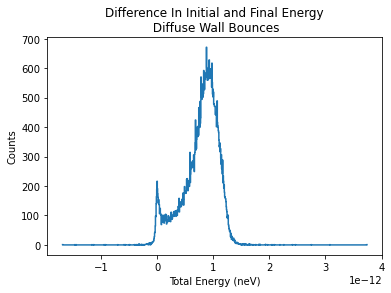

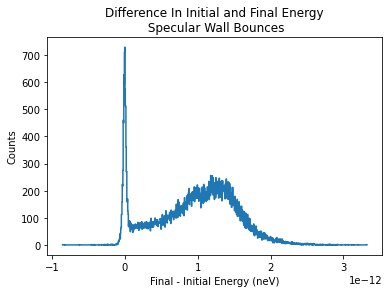

In [13]:
bins = 1000
hist1, b = np.histogram(initEnergyDiff-finalEnergyDiff, bins)
plt.step(b[:-1], hist1)
plt.xlabel('Total Energy (neV)')
plt.ylabel('Counts')
plt.title('Difference In Initial and Final Energy\n Diffuse Wall Bounces')
plt.show()

hist1, b = np.histogram(initEnergySpec-finalEnergySpec, bins)
plt.step(b[:-1], hist1)
plt.xlabel('Final - Initial Energy (neV)')
plt.ylabel('Counts')
plt.title('Difference In Initial and Final Energy\n Specular Wall Bounces')
plt.show()